# State of the Union Addresses Analysis Project

### **Introduction**
Every year, the President of the United States gives a State of the Union (SOTU) Address to the Congress. In more recent times, the addresses have been televised, creating a politcal event with high-coverage and commentary by the media and the public. As a result, many speeches are carefully crafted to ensure that intended messages and ideals are relayed to the public.

The American Presidency Project through the University of California, Santa Barbara provides transcripts of each SOTU Address by each American President (https://www.presidency.ucsb.edu/documents/presidential-documents-archive-guidebook/annual-messages-congress-the-state-the-union). This project scrapes these transcripts and converts the HTML into readable Python objects for analysis.

### **Research Goal and Question:**

This project intends to explore the changes in SOTU Addresses in modern American history, with a special focus on addresses from 1985 to 2025 (Ronald Reagan's presidency to Donald Trump's presidency).

Specfically, I will look at counts of key words reflecting themes of and calls to "American Ideals." I am interested in seeing if there is a relationship between frequencies of word counts and party, president, and/or year to investigate if there might be a pattern or intentionality in emphasizing certain "American ideals".

**The 10 key words include "god", "freedom", "democracy", "justice", "truth", "future", "our nation", "our country", "middle class", and "american dream".**

Notes:
- Many words not explored may be associated with similar ideals (ex. "freedom" and "liberty" are similar). However, for the purposes of this project, I am interested in explicit usage of the 10 key words.
- These words were chosen due to higher key word counts in initial data exploration. Words including substrings like "patriot", "diversity", "vote", and "partisan" did not yield as many counts compared to the chosen words.   



In [1]:
# import relevant packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

## Reading in and Transforming the Data

The following section provides the code for creating the `full_speeches` dataset used for analysis.



#### Read in the Data

Below, the `speeches45.csv` data is assigned to the table `speeches`.

- Note: Please see the "DACSS 611: Code for Project Data.ipynb" file for the code that creates the `speeches45.csv` dataset.

In [2]:
# Please ensure that the speeches45.csv file is uploaded to Google Colab!
speeches = pd.read_csv('speeches45.csv')

#### Adding Relevant Columns

In the following code chunks, the `president`, `party`, key word counts, and key word frequency columns are created.

1. Creating the `president` name column:

In [3]:
# Assign president names to each speech:
def president_name(year):
    if year == 2025:
        return 'D. Trump'
    elif 2021 <= year <= 2024:
        return 'J. Biden'
    elif 2017 <= year <= 2020:
        return 'D. Trump'
    elif 2009 <= year <= 2016:
        return 'B. Obama'
    elif 2001 <= year <= 2008:
        return 'G. W. Bush'
    elif 1993 <= year <= 2000:
        return 'B. Clinton'
    elif 1989 <= year <= 1992:
        return 'G. H.W. Bush'
    elif 1981 <= year <= 1988:
        return 'R. Reagan'

In [4]:
speeches['president'] = speeches['year'].apply(president_name)
speeches = speeches.sort_values(by='year', ascending=True).reset_index(drop=True)

2. For the `party` column, a value of 0 represents the Republican Party and a value of 1 represents the Democratic Party:

In [5]:
# Assign parties to each speech:
def president_party(president):
    if president in ['D. Trump', 'G. W. Bush', 'G. H.W. Bush', 'R. Reagan']:
        return 0
    if president in ['J. Biden', 'B. Obama', 'B. Clinton']:
        return 1

In [6]:
speeches['party'] = speeches['president'].apply(president_party)

3. Below, the `first_speeches` table is created. This includes the first speeches for each presidential term (the first speech following an election).

In [7]:
first_speeches = speeches.groupby('president').nth([0,4]).reset_index()
first_speeches['first_of_term'] = True

4. The `first_speeches` table is then merged with the `speeches` table, resulting in a `first_of_term` column with boolean values indicating whether the speech is the first speech after an election.

In [8]:
speeches = speeches.merge(
    first_speeches[['president','year', 'first_of_term']], on=['president', 'year'], how='left'
)
speeches['first_of_term'] = speeches['first_of_term'].fillna(False)

/tmp/ipython-input-3159736791.py:4: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  speeches['first_of_term'] = speeches['first_of_term'].fillna(False)


5. Next, columns for counts of each keyword per speech are created.
  - The 10 key words: god, freedom, democracy, justice, truth, future, our nation, our country, middle class, and American Dream


In [9]:
keyword_counts = []

for speech in speeches['speech_text']:
    keyword_rows = {
        'speech_text': speech,
        'god_ct': speech.count('god'),
        'freedom_ct': speech.count('freedom'),
        'democracy_ct': speech.count('democracy'),
        'justice_ct': speech.count('justice'),
        'truth_ct': speech.count('truth'),
        'future_ct': speech.count('future'),
        'our_nation_ct': speech.count('our nation'),
        'our_country_ct': speech.count('our country'),
        'middle_class_ct': speech.count('middle class'),
        'american_dream_ct': speech.count('american dream')
    }
    keyword_counts.append(keyword_rows)
speeches_df = pd.DataFrame(keyword_counts)

In [10]:
full_speeches = pd.merge(speeches, speeches_df, on='speech_text', how='inner')

In [11]:
full_speeches = full_speeches.drop(['speech_text', 'link'], axis=1)

5. Lastly, columns for the ***frequency*** of each keyword are created.
  - Key word frequency calculation: (key word count) / (total word count)

In [12]:
cols = ['god_ct', 'freedom_ct', 'democracy_ct', 'justice_ct', 'truth_ct',
              'future_ct', 'our_nation_ct', 'our_country_ct', 'middle_class_ct',
              'american_dream_ct']

for col in cols:
    col_name = col.replace('_ct', '_freq')
    full_speeches[col_name] = full_speeches[col] / full_speeches['word_count']

**Result**: The new dataframe, `full_speeches` with relevant data for analysis.

#### Entire `full_speeches` Table:

In [13]:
full_speeches

,year,word_count,president,party,first_of_term,god_ct,freedom_ct,democracy_ct,justice_ct,truth_ct,...,god_freq,freedom_freq,democracy_freq,justice_freq,truth_freq,future_freq,our_nation_freq,our_country_freq,middle_class_freq,american_dream_freq
0,1981,4446,R. Reagan,0,True,0,0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000450,0.001125,0.000000,0.000000,0.000000
1,1982,5154,R. Reagan,0,False,3,6,0,1,2,...,0.000582,0.001164,0.000000,0.000194,0.000388,0.001746,0.001358,0.000388,0.000000,0.000000
2,1983,5554,R. Reagan,0,False,2,10,2,2,1,...,0.000360,0.001801,0.000360,0.000360,0.000180,0.001981,0.001080,0.000900,0.000000,0.000000
3,1984,4931,R. Reagan,0,False,10,13,3,0,0,...,0.002028,0.002636,0.000608,0.000000,0.000000,0.002028,0.000000,0.000406,0.000000,0.000203
4,1985,4214,R. Reagan,0,True,3,20,2,2,1,...,0.000712,0.004746,0.000475,0.000475,0.000237,0.001424,0.000237,0.000237,0.000000,0.000000
5,1986,3514,R. Reagan,0,False,6,10,3,1,1,...,0.001707,0.002846,0.000854,0.000285,0.000285,0.004553,0.001138,0.000000,0.000000,0.000569
6,1987,3847,R. Reagan,0,False,3,14,2,1,0,...,0.000780,0.003639,0.000520,0.000260,0.000000,0.001560,0.002080,0.000260,0.000000,0.000000
7,1988,4955,R. Reagan,0,False,3,21,7,0,0,...,0.000605,0.004238,0.001413,0.000000,0.000000,0.002624,0.000605,0.000807,0.000000,0.000202
8,1989,4811,G. H.W. Bush,0,True,2,5,3,1,0,...,0.000416,0.001039,0.000624,0.000208,0.000000,0.003118,0.001039,0.000000,0.000000,0.000000
9,1990,3777,G. H.W. Bush,0,False,4,11,7,0,1,...,0.001059,0.002912,0.001853,0.000000,0.000265,0.003177,0.000794,0.000000,0.000000,0.000000


## Descriptive Statistics

1. Dimensions of `full_speeches`:


In [14]:
full_speeches.shape

(45, 25)

- There are 45 rows in the table, each representing a State of the Union Address from 1981 to 2025.
- There are 25 columns representing variables for each speech, including:
  - the `year` the speech was made
  - the total `word_count` for each speech
  - the `president` giving the address
  - the president's `party` affiliation
  - the `first_of_term` variable determining whether it is the first speech of the term
  - columns for the counts for each key word
  = columns for the frequencies of each key word


2. Exploring Minimums, Maximums, Means, and Sums
  
  (Written summary of descriptive stats is below the coding.)

In [15]:
# word_count
print('The minimum speech word count is', full_speeches['word_count'].min(), 'words.')
print('The maximum speech word count is', full_speeches['word_count'].max(), 'words.')
print('The average speech word count is', full_speeches['word_count'].mean(), 'words.')

The minimum speech word count is 3514 words.
The maximum speech word count is 9906 words.
The average speech word count is 6063.4 words.


In [16]:
# party
n_1st_term = full_speeches['party'].value_counts()
print(n_1st_term)

party
0    25
1    20
Name: count, dtype: int64


In [17]:
# first_of_term
n_1st_term = full_speeches['first_of_term'].value_counts()
print(n_1st_term)

first_of_term
False    33
True     12
Name: count, dtype: int64


In [18]:
full_speeches.columns

Index(['year', 'word_count', 'president', 'party', 'first_of_term', 'god_ct',
       'freedom_ct', 'democracy_ct', 'justice_ct', 'truth_ct', 'future_ct',
       'our_nation_ct', 'our_country_ct', 'middle_class_ct',
       'american_dream_ct', 'god_freq', 'freedom_freq', 'democracy_freq',
       'justice_freq', 'truth_freq', 'future_freq', 'our_nation_freq',
       'our_country_freq', 'middle_class_freq', 'american_dream_freq'],
      dtype='object')

In [19]:
# keyword count (finds highest count for *each word* across all speeches)
max_keyword_cts = (full_speeches[['god_ct','freedom_ct', 'democracy_ct', 'justice_ct', 'truth_ct',
               'future_ct', 'our_nation_ct', 'our_country_ct',
               'middle_class_ct', 'american_dream_ct']].max().reset_index()).sort_values(0, ascending=True)

print(max_keyword_cts)

               index   0
4           truth_ct   3
9  american_dream_ct   3
8    middle_class_ct   8
0             god_ct  10
3         justice_ct  13
6      our_nation_ct  15
2       democracy_ct  17
1         freedom_ct  21
5          future_ct  23
7     our_country_ct  32


- `word_count`: The total word counts for speeches range between 3,514 words and 9,906 words, with the average speech being 6,063.4 words.
- `party`: 25 speeches were from a Republican president and 20 were from a Democrat president.
- `first_of_term`: 12 of the speeches were the first speeches after an election, and 33 of the speeches were not the first speeches after an election.
- Keyword Counts: The keyword with the maximum number of occurences in a single speech was "our country" at 32 occurences. There are several instances where a keyword did not appear at all in a speech.

3. Missing Values

In [20]:
full_speeches.isnull().values.any()

np.False_

- There are no missing values in the `full_speeches` dataset.

## Analysis and Visualizations

Below are explorations of key analyses found during intial data exploration. These explorations include exploring the relationships between the following variables:

- Total Word Count and Time
- Frequencies of "Our Nation" and "Our Country" by Party
- Frequency of "Middle Class" by Party
- Frequecy of "God" or "god" and Time
- Frequecy of "God" or "god", First-Speech-of-Term Status, and Party

For each exploration, plots are made, OLS Regression Models are ran, and written analysess of the relationship are provided.

#### Total Word Count Overtime

First, I will explore the total word count of speeches over time using the `year` and `word_count` column in the `full_speeches` dataframe:

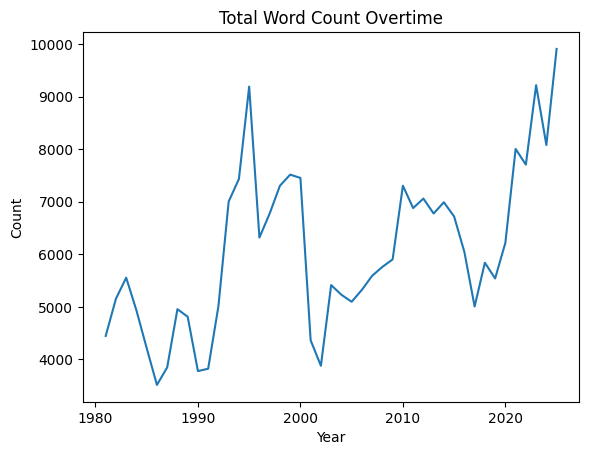

                            OLS Regression Results                            
Dep. Variable:             word_count   R-squared:                       0.326
Model:                            OLS   Adj. R-squared:                  0.310
Method:                 Least Squares   F-statistic:                     20.76
Date:                Tue, 19 Aug 2025   Prob (F-statistic):           4.26e-05
Time:                        07:54:28   Log-Likelihood:                -384.89
No. Observations:                  45   AIC:                             773.8
Df Residuals:                      43   BIC:                             777.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1.283e+05   2.95e+04     -4.351      0.0

In [21]:
# Word Count vs Time Line Plot
full_speeches.plot.line(x='year', y='word_count', legend=False)
plt.title('Total Word Count Overtime')
plt.xlabel('Year')
plt.ylabel('Count')
plt.show()

# Word Count vs Time OLS Regression Model
X = sm.add_constant(full_speeches['year'])
y = full_speeches['word_count']

model = sm.OLS(y, X).fit()
print(model.summary())

**Analysis**:

In the "Total Word Count Overtime" plot, we can see spikes in total word count of SOTU speeches, with a general trend upwards overtime.

Looking at the OLS Regression Model, it appears that there is a significant relationship between total word count and time, with the word count of speeches increasing by about 67 words per year. The coefficient (67.0914 words) falls between the confidence interval range of 37.397 and 96.786 words, and the effect of `year` is likely signicant in the outcome variable of `word_count`.

There may need to be further analysis to determine the strength of this relationship, as the model summary notes that there might be strong multicollinearity or other numerical problems.

#### Use of "Our Nation" and "Our Country" by Party

Next, I will explore the use of "our nation" and "our country" in speeches, specifically looking at word frequencies by party (Republican and Democrat) in SOTU Speeches.

In [22]:
# Group By Party (df) for plotting
speeches_by_party = full_speeches.groupby('party')[
    ['word_count', 'god_freq', 'freedom_freq', 'democracy_freq',
       'justice_freq', 'truth_freq', 'future_freq', 'our_nation_freq',
       'our_country_freq', 'middle_class_freq', 'american_dream_freq']].mean().reset_index()
party_labels = {0: 'Republican', 1: 'Democrat'}
speeches_by_party['party_id'] = speeches_by_party['party'].map(party_labels)
speeches_by_party

,party,word_count,god_freq,freedom_freq,democracy_freq,justice_freq,truth_freq,future_freq,our_nation_freq,our_country_freq,middle_class_freq,american_dream_freq,party_id
0,0,5087.88,0.000667,0.002032,0.000490,0.000419,0.000115,0.00162,0.001197,0.001250,0.000053,0.000071,Republican
1,1,7282.80,0.000388,0.000436,0.000627,0.000291,0.000152,0.00124,0.000585,0.000441,0.000447,0.000082,Democrat


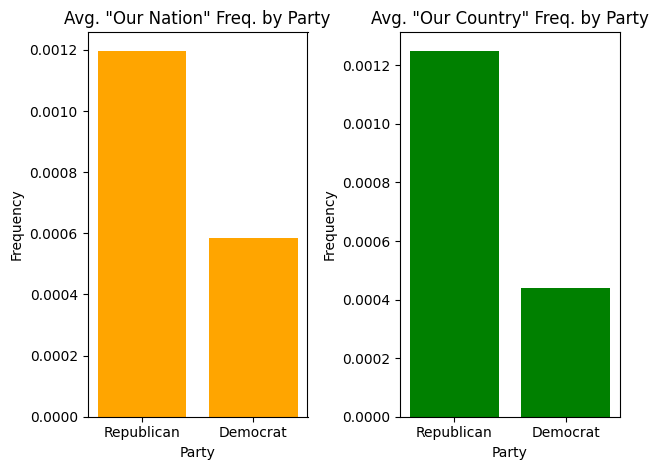

In [23]:
# Plot: our_country and our_nation by party
fig, (ax1, ax2) = plt.subplots(1,2)
ax1.bar(speeches_by_party['party_id'], speeches_by_party['our_nation_freq'], color='orange')
ax1.set_title('Avg. "Our Nation" Freq. by Party')
ax1.set_xlabel('Party')
ax1.set_ylabel('Frequency')


ax2.bar(speeches_by_party['party_id'], speeches_by_party['our_country_freq'], color='green')
ax2.set_title('Avg. "Our Country" Freq. by Party')
ax2.set_xlabel('Party')
ax2.set_ylabel('Frequency')

plt.tight_layout()

In [24]:
# OLS: our_nation by party

X = sm.add_constant(full_speeches['party'])
y = full_speeches['our_nation_freq']

model = sm.OLS(y, X).fit()
print(model.summary())

print("==============================================================================")
print("==============================================================================")
# Plot: our_country by party

X = sm.add_constant(full_speeches['party'])
y = full_speeches['our_country_freq']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        our_nation_freq   R-squared:                       0.209
Model:                            OLS   Adj. R-squared:                  0.191
Method:                 Least Squares   F-statistic:                     11.36
Date:                Tue, 19 Aug 2025   Prob (F-statistic):            0.00159
Time:                        07:54:29   Log-Likelihood:                 270.59
No. Observations:                  45   AIC:                            -537.2
Df Residuals:                      43   BIC:                            -533.6
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0012      0.000      9.887      0.0

**Analysis**:

In the bar plots, the average frequency of "our nation" and "our country" is dispalyed by party. Based on the plot, the Republican presidents tended to use these terms in SOTU addresses more than Democrat presidents have.

The OLS Regression results strengthen this observation of the relationship between frequencies of these terms and political party. The coefficients for both "our nation" and "our country" frequencies fall between a the confidence intervals, and these confidence intervals do not include 0. The p-value also is less than 0.05, making the relationship statistically significant.

These findings could possibly suggest that Republican presidents tend to use these terms more for emphasizing a national identity. Further text analysis could explore this assertion.

#### "Middle Class" and Party

Next, an exploration of frequency of the key word "middle class" by party in SOTU Speeches.

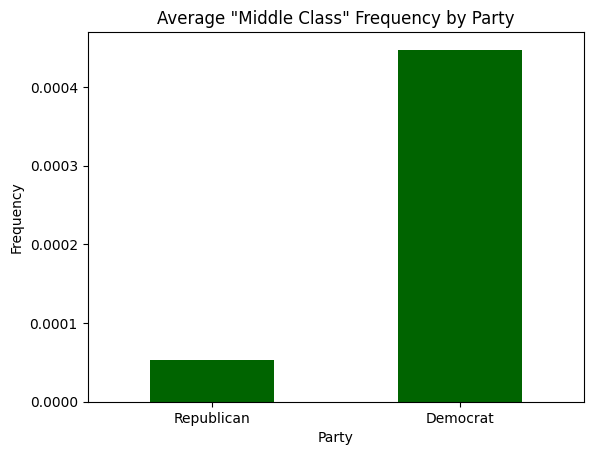

                            OLS Regression Results                            
Dep. Variable:      middle_class_freq   R-squared:                       0.386
Model:                            OLS   Adj. R-squared:                  0.372
Method:                 Least Squares   F-statistic:                     27.03
Date:                Tue, 19 Aug 2025   Prob (F-statistic):           5.27e-06
Time:                        07:54:29   Log-Likelihood:                 309.94
No. Observations:                  45   AIC:                            -615.9
Df Residuals:                      43   BIC:                            -612.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       5.324e-05   5.05e-05      1.054      0.2

In [25]:
# Plot: middle_class by party
speeches_by_party.plot.bar(x='party_id', y='middle_class_freq', color='darkgreen',legend=False)
plt.title('Average "Middle Class" Frequency by Party')
plt.xlabel('Party')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

# OLS: middle_class by party

X = sm.add_constant(full_speeches['party'])
y = full_speeches['middle_class_freq']

model = sm.OLS(y, X).fit()
print(model.summary())

**Analysis**:

In the "Average "Middle Class" Frequency by Party" plot, there appears to be a significant difference in the frequency of "middle class" occurences in SOTU Speeches, with Democrat presidents tending to use the term more than Republican presidents.

The OLS Regresssion Model suggests that the relationship between the frequency of "middle class" and political party, with Democrat presidents being more  likely to have higher frequencies of the term in their SOTU speeches.

The "middle class" is a popular American political ideal, and the frequency rates of the term align with assertions that Democrat platforms tend to discuss middle class issues.

#### "God" and Year of Speech

This next section explores the frequency of "god" in SOTU speeches overtime.

- Note: Counts of this key word include counts of hyphenated words like "god-given" and "god-awful" as well. The intention is to count any use of "god", even if the occurence does not directly reference "god" or "God" as a religious figure or concept.

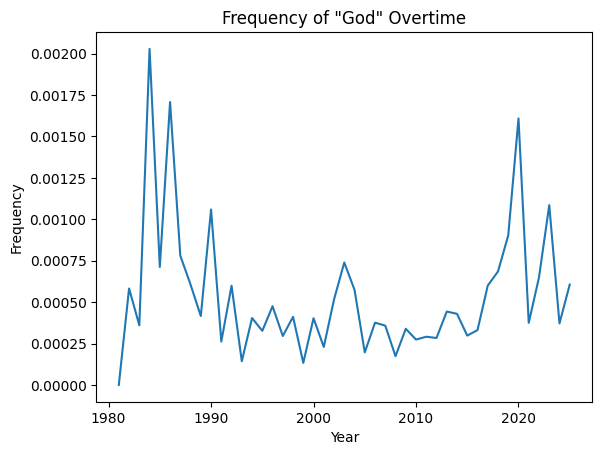

                            OLS Regression Results                            
Dep. Variable:               god_freq   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.019
Method:                 Least Squares   F-statistic:                    0.1892
Date:                Tue, 19 Aug 2025   Prob (F-statistic):              0.666
Time:                        07:54:29   Log-Likelihood:                 287.93
No. Observations:                  45   AIC:                            -571.9
Df Residuals:                      43   BIC:                            -568.3
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0047      0.009      0.492      0.6

In [26]:
# Plot: god and party
full_speeches.plot.line(x='year', y='god_freq', legend=False)
plt.title('Frequency of "God" Overtime')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

# OLS: god and year
X = sm.add_constant(full_speeches['year'])
y = full_speeches['god_freq']

model = sm.OLS(y, X).fit()
print(model.summary())

**Analysis**:

The "Frequency of "God" Overtime" plot displays the usage of "God" or "god" in speeches overtime. It looks like there are major peaks around the 1980s and 2020s, with lower frequencies in between.

The OLS Regression model suggests that the relationship between the frequency of this key word and time are not statistically significant. In other words, presidents are not more likely or less likely to use "God" or "god" in speeches overtime.

However, the peaks in frequency are still interesting and may warrant further reserach as to why the peaks occurred at those times. For example, the social or politcal state of the country at the time of the address may have influenced more appeals to religion in SOTU speeches. Or, the religous background of the president may have a strong relationship with the use of "God" in the speech.

### Frequency of God, First Speech of Term Status, and Party

Looking further into the frequency of "God", I am looking at the `first_of_term` and `party` variables.

In [27]:
# First Speech Status df for plotting
speeches_by_1st_of_term = full_speeches.groupby('first_of_term')[
    ['word_count', 'god_freq', 'freedom_freq', 'democracy_freq',
       'justice_freq', 'truth_freq', 'future_freq', 'our_nation_freq',
       'our_country_freq', 'middle_class_freq', 'american_dream_freq']].mean().reset_index()
speeches_by_1st_of_term

,first_of_term,word_count,god_freq,freedom_freq,democracy_freq,justice_freq,truth_freq,future_freq,our_nation_freq,our_country_freq,middle_class_freq,american_dream_freq
0,False,6077.424242,0.000608,0.001380,0.000545,0.000344,0.000144,0.001490,0.000918,0.000866,0.000220,0.000090
1,True,6024.833333,0.000363,0.001164,0.000568,0.000412,0.000097,0.001345,0.000947,0.000959,0.000251,0.000037


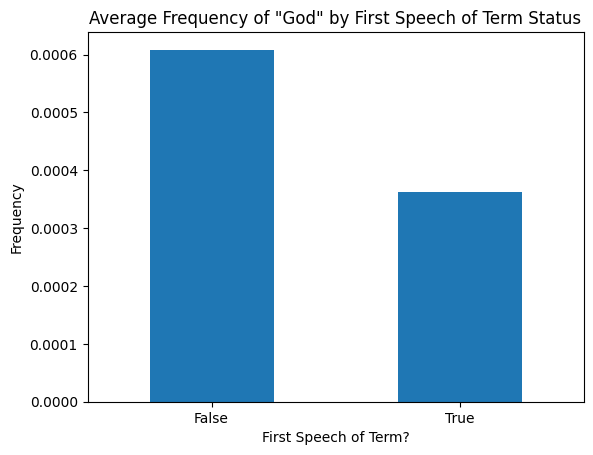

                            OLS Regression Results                            
Dep. Variable:               god_freq   R-squared:                       0.072
Model:                            OLS   Adj. R-squared:                  0.051
Method:                 Least Squares   F-statistic:                     3.360
Date:                Tue, 19 Aug 2025   Prob (F-statistic):             0.0737
Time:                        07:54:30   Log-Likelihood:                 289.53
No. Observations:                  45   AIC:                            -575.1
Df Residuals:                      43   BIC:                            -571.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0006   6.92e-05      8.791

In [28]:
# Plot: god-freq by first_of_term
speeches_by_1st_of_term.plot.bar(x='first_of_term', y='god_freq', legend=False)
plt.title('Average Frequency of "God" by First Speech of Term Status')
plt.xlabel('First Speech of Term?')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

#OLS: god-freq by first_of_term
full_speeches['first_of_term'] = full_speeches['first_of_term'].astype(int)

X = sm.add_constant(full_speeches['first_of_term'])
y = full_speeches['god_freq']

model = sm.OLS(y, X).fit()
print(model.summary())

**Analysis**:

It appears that there is not enough evidence to suggest a statistically significant relationship between the frequency of "god" and the first term of speech status. The p-value is 0.074, which is slightly greater than 0.05. The coefficeient does fall into the confidence interval range, but this range includes 0.

Next, I will explore the relationship between the frequency of "god" and the politcal `party` variable.

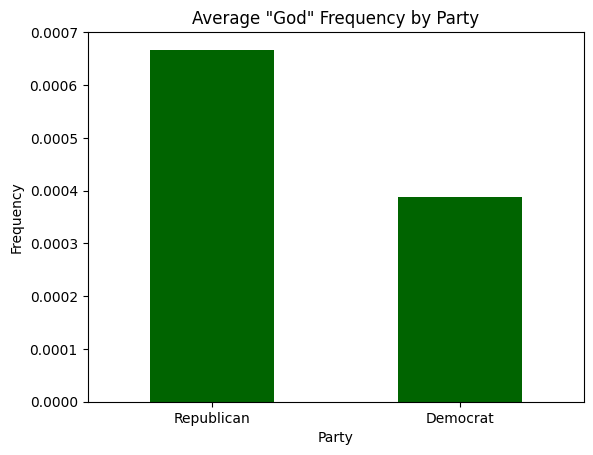

                            OLS Regression Results                            
Dep. Variable:               god_freq   R-squared:                       0.118
Model:                            OLS   Adj. R-squared:                  0.098
Method:                 Least Squares   F-statistic:                     5.755
Date:                Tue, 19 Aug 2025   Prob (F-statistic):             0.0208
Time:                        07:54:31   Log-Likelihood:                 290.66
No. Observations:                  45   AIC:                            -577.3
Df Residuals:                      43   BIC:                            -573.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0007   7.75e-05      8.601      0.0

In [29]:
# Plot: god_freq by party
speeches_by_party.plot.bar(x='party_id', y='god_freq', color='darkgreen',legend=False)
plt.title('Average "God" Frequency by Party')
plt.xlabel('Party')
plt.ylabel('Frequency')
plt.xticks(rotation=0)
plt.show()

# OLS: god_freq by party

X = sm.add_constant(full_speeches['party'])
y = full_speeches['god_freq']

model = sm.OLS(y, X).fit()
print(model.summary())

Based on the "Average "God" Frequency by Party" plot and the OLS Regression model, there is a statistically significant relastionship between the frequency of "god" and party, with Republican presidents having higher frequencies of usage. The coefficient lies between the confidence interval values, and the p-value is less than 0.05.

For further exploration, I will look at the relationships between the `god_freq`, `first_of_term`, and `party` variables:

In [30]:
# OLS: god_freq, first_of_term, party
full_speeches['first_of_term'] = full_speeches['first_of_term'].astype(int)

X = sm.add_constant(full_speeches[['first_of_term', 'party']])
y = full_speeches['god_freq']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:               god_freq   R-squared:                       0.197
Model:                            OLS   Adj. R-squared:                  0.159
Method:                 Least Squares   F-statistic:                     5.151
Date:                Tue, 19 Aug 2025   Prob (F-statistic):            0.00998
Time:                        07:54:31   Log-Likelihood:                 292.77
No. Observations:                  45   AIC:                            -579.5
Df Residuals:                      42   BIC:                            -574.1
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.0007   8.28e-05      8.923

**Analysis**:

In the OLS Model above, the `first_of_term` variable becomes statistically significant when combined with `party`. The model suggests that Republicans use "god" more often than Democrats, and that the higher usages of "god" may occur more in later speeches (SOTU addresses that do not directly follow an election).

There could be many reasons resulting in these frequency differences, including national crises, incumbency or electoral runs, or coincidence.

## Conclusion

Upon exploring the effects of politcal party, first-of-term speech status, time, and occurences of key political words, many possible relationships were uncovered. The total word count of SOTU speeches generally increased over time, Republicans tended to use "our country" and "our nation" in speeches more than Democrats, Democrats tended to use the term "middle class" more, and interesting observations regarding the frequency of "god" in speeches were explored.

This project offers a brief exploration of the many relationships that could be explored in SOTU Speech data, and more advanced text analysis could surely uncover more concrete insghts about rhetoric and message framing. based on what has been explored in this project, there does appear to be patterns of word usage that could suggest intentional or unintentional rallying based on various entrenched "American Ideals", including religion and national identity.